In [222]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [223]:
df=pd.read_csv('social_media_screentime_mental_health_2026.csv')
df.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [224]:
df.drop(['participant_id','region','occupation','primary_purpose','most_used_platform'], axis=1, inplace=True)

In [225]:
df.isnull().sum()

age                                      0
gender                                  70
platforms_used_count                     0
daily_screen_hours                       0
daily_notifications                      0
night_time_use                           0
minutes_to_first_check_after_waking      0
avg_sleep_hours                        105
anxiety_score_0to27                      0
low_mood_score_0to27                     0
life_satisfaction_1to10                  0
loneliness_1to10                         0
self_esteem_1to10                        0
fomo_1to10                               0
social_comparison_1to10                  0
physical_activity_days_per_week          0
uses_screen_time_limits                  0
attempted_digital_detox                  0
seeks_mental_health_support              0
wellbeing_band                           0
dtype: int64

In [226]:
df.dropna().reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  7000 non-null   int64  
 1   gender                               6930 non-null   str    
 2   platforms_used_count                 7000 non-null   int64  
 3   daily_screen_hours                   7000 non-null   float64
 4   daily_notifications                  7000 non-null   int64  
 5   night_time_use                       7000 non-null   str    
 6   minutes_to_first_check_after_waking  7000 non-null   int64  
 7   avg_sleep_hours                      6895 non-null   float64
 8   anxiety_score_0to27                  7000 non-null   int64  
 9   low_mood_score_0to27                 7000 non-null   int64  
 10  life_satisfaction_1to10              7000 non-null   int64  
 11  loneliness_1to10                     7000

In [227]:
df.drop(['gender','night_time_use','uses_screen_time_limits','attempted_digital_detox','seeks_mental_health_support','wellbeing_band'], axis=1, inplace=True)

In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  7000 non-null   int64  
 1   platforms_used_count                 7000 non-null   int64  
 2   daily_screen_hours                   7000 non-null   float64
 3   daily_notifications                  7000 non-null   int64  
 4   minutes_to_first_check_after_waking  7000 non-null   int64  
 5   avg_sleep_hours                      6895 non-null   float64
 6   anxiety_score_0to27                  7000 non-null   int64  
 7   low_mood_score_0to27                 7000 non-null   int64  
 8   life_satisfaction_1to10              7000 non-null   int64  
 9   loneliness_1to10                     7000 non-null   int64  
 10  self_esteem_1to10                    7000 non-null   int64  
 11  fomo_1to10                           7000

In [229]:
x=df.drop(['life_satisfaction_1to10'], axis=1)
y=df['life_satisfaction_1to10']
x.fillna(x.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)


0        9
1        7
2        8
3       10
4        4
        ..
6995     4
6996     8
6997     9
6998     5
6999     5
Name: life_satisfaction_1to10, Length: 7000, dtype: int64

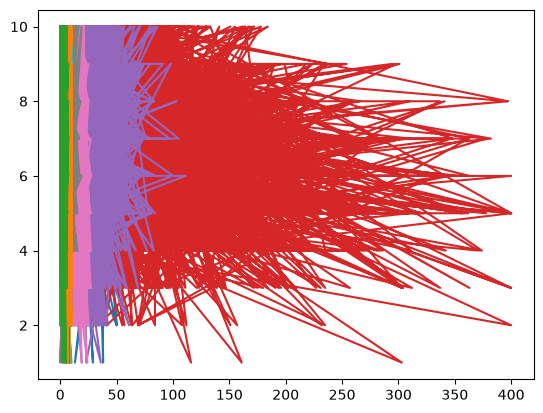

In [230]:
plt.plot(x,y)

In [231]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.25, random_state=42)


In [232]:
x_train.corr()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
age,1.000000,0.008301,0.005587,0.011249,0.000220,0.007161,-0.000242,-0.009942,-0.006811,-0.018251,-0.000238,-0.020678,-0.024721
platforms_used_count,0.008301,1.000000,-0.007263,0.008429,-0.008477,0.008237,-0.000841,-0.004728,-0.137532,0.008794,-0.015730,0.001230,-0.019838
daily_screen_hours,0.005587,-0.007263,1.000000,0.610147,0.009504,-0.375538,0.515679,-0.354125,0.334235,-0.298143,0.427224,0.342093,0.011439
daily_notifications,0.011249,0.008429,0.610147,1.000000,-0.020123,-0.236339,0.321885,-0.225406,0.211476,-0.182423,0.250040,0.188766,0.005994
minutes_to_first_check_after_waking,0.000220,-0.008477,0.009504,-0.020123,1.000000,0.004492,0.000340,-0.017338,0.012890,-0.029692,-0.018087,-0.006386,-0.006470
avg_sleep_hours,0.007161,0.008237,-0.375538,-0.236339,0.004492,1.000000,-0.249557,0.188635,-0.133657,0.121670,-0.158578,-0.128832,-0.001749
anxiety_score_0to27,-0.000242,-0.000841,0.515679,0.321885,0.000340,-0.249557,1.000000,-0.186030,0.169543,-0.138552,0.226010,0.168227,0.000279
low_mood_score_0to27,-0.009942,-0.004728,-0.354125,-0.225406,-0.017338,0.188635,-0.186030,1.000000,-0.123871,0.114962,-0.152457,-0.125352,0.011486
loneliness_1to10,-0.006811,-0.137532,0.334235,0.211476,0.012890,-0.133657,0.169543,-0.123871,1.000000,-0.105861,0.151560,0.110918,0.023880
self_esteem_1to10,-0.018251,0.008794,-0.298143,-0.182423,-0.029692,0.121670,-0.138552,0.114962,-0.105861,1.000000,-0.130442,-0.110819,0.016105


<Axes: >

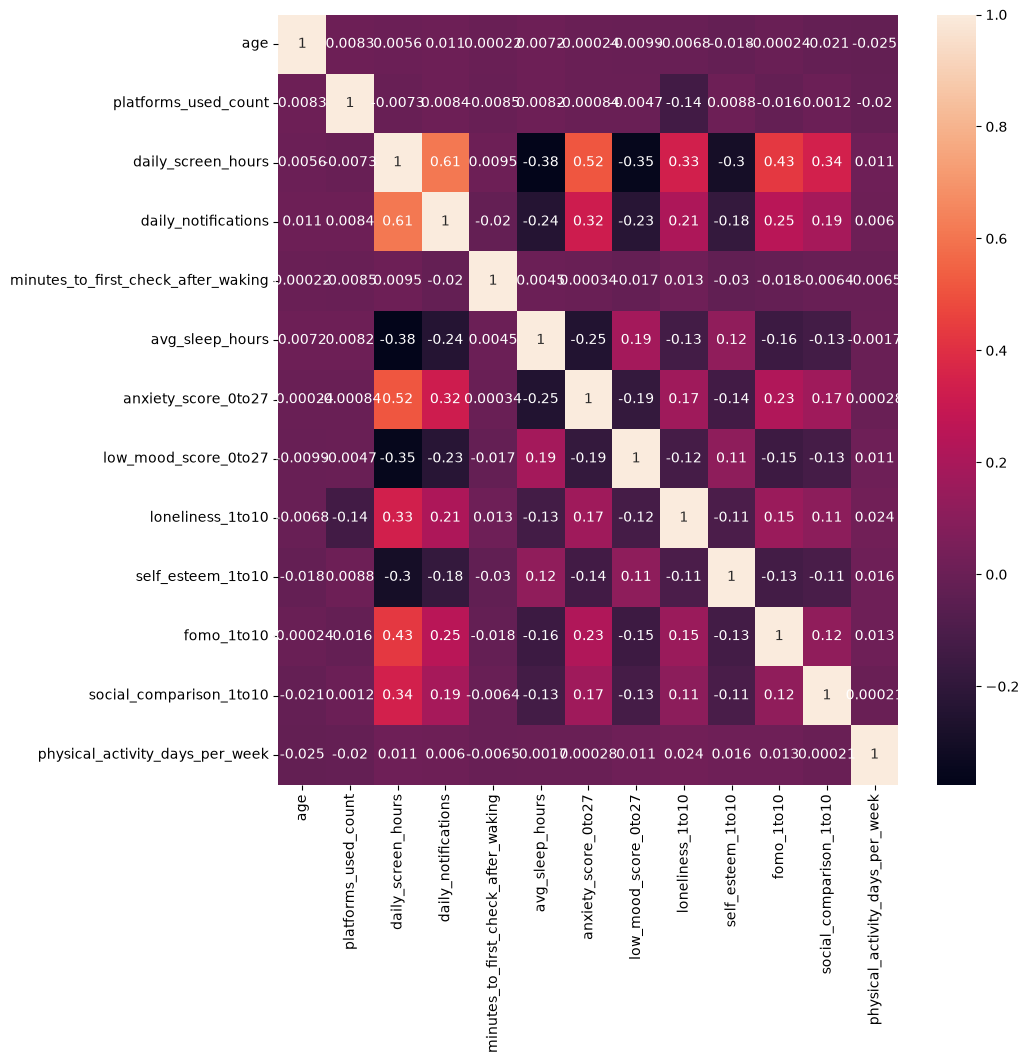

In [233]:
plt.figure(figsize=(10, 10))
corr=x_train.corr()
sns.heatmap(corr, annot=True)

In [234]:
def correlation(dataset, threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr            

In [235]:
correlation(x_train, 0.60)

{'daily_notifications'}

In [236]:
x_train.fillna(x_train.mean(), inplace=True)
x_test.fillna(x_test.mean(), inplace=True)

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
6500,32,1,5.1,100,11,8.5,4,4,7,6,4,7,1
2944,28,5,1.7,15,55,7.9,3,5,5,7,3,3,4
2024,28,2,9.2,93,26,5.9,16,0,8,6,4,5,4
263,31,4,8.7,64,16,6.7,20,0,8,5,6,7,1
4350,28,6,3.8,68,7,7.2,9,4,6,7,5,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,32,7,4.3,48,7,6.8,12,0,8,4,5,7,3
5653,13,3,2.5,55,27,7.0,10,0,6,8,4,6,3
2018,23,4,8.5,18,41,6.8,11,0,9,4,8,5,4
2407,21,3,2.0,51,41,7.3,9,2,4,8,1,4,2


In [237]:
x

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
0,33,8,3.2,172,25,8.7,17,0,6,4,6,8,4
1,23,8,4.5,38,26,7.3,18,2,5,8,5,8,4
2,56,1,5.3,74,12,7.0,12,6,7,3,2,3,5
3,13,4,3.4,49,21,7.0,13,0,6,6,1,5,4
4,36,5,5.8,227,19,6.7,15,1,6,8,7,9,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,30,4,3.6,74,7,5.9,2,8,4,6,3,10,2
6996,28,3,5.0,104,48,5.8,13,0,1,7,6,7,1
6997,26,3,1.2,25,6,8.6,8,9,4,5,1,6,3
6998,22,4,3.6,182,12,7.3,9,4,7,4,1,6,2


In [238]:
x_test.isnull().sum()

age                                    0
platforms_used_count                   0
daily_screen_hours                     0
daily_notifications                    0
minutes_to_first_check_after_waking    0
avg_sleep_hours                        0
anxiety_score_0to27                    0
low_mood_score_0to27                   0
loneliness_1to10                       0
self_esteem_1to10                      0
fomo_1to10                             0
social_comparison_1to10                0
physical_activity_days_per_week        0
dtype: int64

In [239]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

Text(0.5, 1.0, 'Graph after scalling')

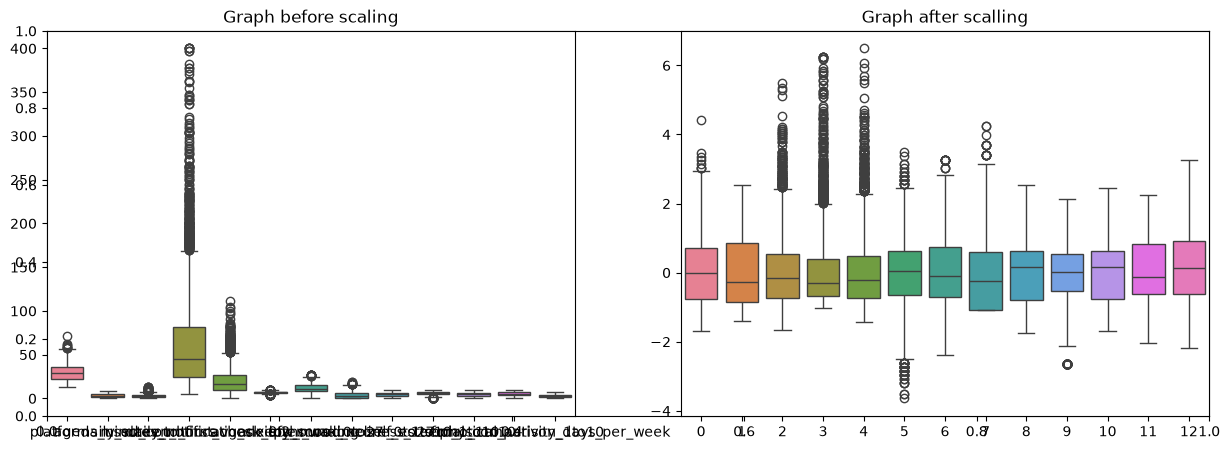

In [240]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title("Graph before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("Graph after scalling")

In [241]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_scaled, y_train)
y_pred=regression.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.2172038729513037
0.16997718985331367


In [242]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=LassoCV(cv=5)
lasso.fit(x_train_scaled, y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.2170434637246736
0.16851289994598662


In [243]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=RidgeCV(cv=5)
ridge.fit(x_train_scaled, y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.2172560765132263
0.16990860722836354


In [244]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNetCV(cv=5)
elastic.fit(x_train_scaled, y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.2173359436331466
0.16808510469938553


In [245]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(x_train_scaled, y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.2746820148699893
0.019693166037233256


In [246]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.286057142857143
-0.0008120797167341376


In [247]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(x_train_scaled, y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print(mae)
print(score)

1.2172090854129658
0.1699703620478359
